<a href="https://colab.research.google.com/github/angeruzzi/recommender_system_movielens/blob/main/03_baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recommendation Baselines — MovieLens 100K

## 1. Introdução

Este notebook implementa modelos baseline para o problema de recomendação utilizando o MovieLens 100K.

Baselines fornecem referências simples de desempenho e permitem avaliar se modelos mais sofisticados realmente adicionam valor.

Serão implementadas duas estratégias:

- **Random Baseline**: recomenda itens aleatoriamente entre os candidatos elegíveis;
- **Popularity Baseline**: recomenda os itens mais populares no conjunto de treino.

Ambos os modelos serão avaliados utilizando o mesmo protocolo definido anteriormente, com split temporal por usuário e métricas Precision@K, Recall@K e NDCG@K.

## 2. Preparação

In [1]:
!wget -q -O utils.py \
    https://raw.githubusercontent.com/angeruzzi/recommender_system_movielens/main/utils.py

In [22]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import utils

#Validação
assert utils.validate_metrics()
assert utils.validate_framework()

print("Framework carregado com sucesso.")

#Configuração experimental:
RELEVANCE_THRESHOLD = 4
TRAIN_RATIO = 0.8
K = 10
RANDOM_STATE = 42

#Carregamento
ratings, movies = utils.load_movielens_100k()

print(f"Ratings: {len(ratings):,}")
print(f"Users:   {ratings['user_id'].nunique():,}")
print(f"Movies:  {ratings['item_id'].nunique():,}")


Framework carregado com sucesso.
Ratings: 100,000
Users:   943
Movies:  1,682


## 3. Protocolo Experimental

Para garantir comparabilidade com os modelos posteriores, os baselines utilizarão o mesmo protocolo experimental definido anteriormente.

As interações de cada usuário serão ordenadas temporalmente e divididas em 80% para treino e 20% para teste.

O ground truth será composto por itens do conjunto de teste com rating igual ou superior a 4 e que estejam presentes no catálogo conhecido durante o treinamento.

Itens já observados pelo usuário no conjunto de treino serão excluídos das recomendações.

In [5]:
train, test = utils.temporal_split_by_user(
    ratings,
    train_ratio=TRAIN_RATIO
)

print(f"Train: {len(train):,}")
print(f"Test:  {len(test):,}")

Train: 79,619
Test:  20,381


In [6]:
temporal_validation = utils.validate_temporal_split(
    train,
    test
)

assert temporal_validation.all()

print("Split temporal validado.")

Split temporal validado.


In [7]:
evaluation_data = utils.build_evaluation_data(
    train=train,
    test=test,
    relevance_threshold=RELEVANCE_THRESHOLD
)

train_catalog = evaluation_data["train_catalog"]
seen_items = evaluation_data["seen_items"]
ground_truth = evaluation_data["evaluable_ground_truth"]
evaluation_users = evaluation_data["evaluation_users"]

print(f"Itens no catálogo de treino: {len(train_catalog):,}")
print(f"Usuários avaliáveis:         {len(evaluation_users):,}")
print(
    f"Novos itens apenas no teste: "
    f"{len(evaluation_data['new_items_in_test']):,}"
)

Itens no catálogo de treino: 1,611
Usuários avaliáveis:         907
Novos itens apenas no teste: 71


## 4. Random Baseline

O Random Baseline gera recomendações selecionando aleatoriamente itens entre os candidatos disponíveis para cada usuário.

Esse modelo não utiliza informações sobre preferências, ratings ou popularidade.

Seu objetivo é fornecer uma referência inferior de desempenho para os demais sistemas de recomendação.

In [8]:
rng = np.random.default_rng(RANDOM_STATE)

random_recommendations = {}

for user_id in evaluation_users:

    candidates = list(
        utils.get_candidate_items(
            user_id=user_id,
            train_catalog=train_catalog,
            seen_items=seen_items
        )
    )

    n_recommendations = min(
        K,
        len(candidates)
    )

    recommended_items = rng.choice(
        candidates,
        size=n_recommendations,
        replace=False
    )

    random_recommendations[user_id] = (
        recommended_items.tolist()
    )

In [9]:
#Exemplo
user_id = evaluation_users[0]

random_recommendations[user_id]

[337, 1299, 341, 1133, 829, 821, 1196, 349, 498, 1421]

In [10]:
random_results, random_summary = (
    utils.evaluate_recommendations(
        recommendations=random_recommendations,
        ground_truth=ground_truth,
        k=K
    )
)

random_summary

{'Precision@10': np.float64(0.007386990077177509),
 'Recall@10': np.float64(0.006948659456428627),
 'NDCG@10': np.float64(0.008208640404913509),
 'n_users': 907}

## 5. Popularity Baseline

O Popularity Baseline recomenda os filmes com maior número de interações no conjunto de treino.

Apesar de não ser personalizado, esse baseline costuma ser significativamente mais competitivo que uma estratégia aleatória, principalmente em datasets com forte concentração de popularidade.

Para cada usuário, filmes já observados no conjunto de treino serão removidos antes da geração da lista Top-K.

In [13]:
item_popularity = (
    train
    .groupby("item_id")
    .size()
    .sort_values(ascending=False)
)

popular_movies = (
    item_popularity
    .rename("n_ratings")
    .reset_index()
    .merge(
        movies[["item_id", "title"]],
        on="item_id",
        how="left"
    )
)

popular_movies.head(10)

,item_id,n_ratings,title
0,50,514,Star Wars (1977)
1,100,471,Fargo (1996)
2,181,460,Return of the Jedi (1983)
3,258,458,Contact (1997)
4,286,443,"English Patient, The (1996)"
5,294,443,Liar Liar (1997)
6,288,433,Scream (1996)
7,300,405,Air Force One (1997)
8,1,399,Toy Story (1995)
9,174,374,Raiders of the Lost Ark (1981)


## 5.2 Gerando recomendações

A lógica é simples:

percorremos os filmes mais populares e ignoramos aqueles que o usuário já viu.

In [14]:
popularity_ranking = item_popularity.index.tolist()

popularity_recommendations = {}

for user_id in evaluation_users:

    seen = seen_items.get(
        user_id,
        set()
    )

    recommendations = [
        item_id
        for item_id in popularity_ranking
        if item_id not in seen
    ][:K]

    popularity_recommendations[user_id] = (
        recommendations
    )

In [18]:
#Exemplo
user_id = evaluation_users[0]

recommended_ids = popularity_recommendations[user_id]

recommended_movies = (
    pd.DataFrame({
        "item_id": recommended_ids,
        "rank": range(
            1,
            len(recommended_ids) + 1
        )
    })
    .merge(
        movies[["item_id", "title"]],
        on="item_id",
        how="left"
    )
    .sort_values("rank")
)

recommended_movies

,item_id,rank,title
0,100,1,Fargo (1996)
1,258,2,Contact (1997)
2,286,3,"English Patient, The (1996)"
3,294,4,Liar Liar (1997)
4,288,5,Scream (1996)
5,300,6,Air Force One (1997)
6,222,7,Star Trek: First Contact (1996)
7,405,8,Mission: Impossible (1996)
8,748,9,"Saint, The (1997)"
9,313,10,Titanic (1997)


### 5.3 Avaliação

In [19]:
popularity_results, popularity_summary = (
    utils.evaluate_recommendations(
        recommendations=popularity_recommendations,
        ground_truth=ground_truth,
        k=K
    )
)

popularity_summary

{'Precision@10': np.float64(0.07750826901874311),
 'Recall@10': np.float64(0.07864556031387435),
 'NDCG@10': np.float64(0.0988828492465869),
 'n_users': 907}

## 6. Comparação dos Baselines

Os resultados dos dois baselines serão comparados utilizando Precision@K, Recall@K e NDCG@K.

O Random Baseline representa uma referência sem uso de informação sobre comportamento ou popularidade.

O Popularity Baseline utiliza apenas a frequência de interações dos itens no conjunto de treino.

Essa comparação permite medir quanto desempenho pode ser obtido apenas explorando a concentração de popularidade existente no dataset.

In [20]:
baseline_comparison = pd.DataFrame([
    {
        "model": "Random",
        f"Precision@{K}": random_summary[f"Precision@{K}"],
        f"Recall@{K}": random_summary[f"Recall@{K}"],
        f"NDCG@{K}": random_summary[f"NDCG@{K}"],
        "n_users": random_summary["n_users"]
    },
    {
        "model": "Popularity",
        f"Precision@{K}": popularity_summary[f"Precision@{K}"],
        f"Recall@{K}": popularity_summary[f"Recall@{K}"],
        f"NDCG@{K}": popularity_summary[f"NDCG@{K}"],
        "n_users": popularity_summary["n_users"]
    }
])

baseline_comparison

,model,Precision@10,Recall@10,NDCG@10,n_users
0,Random,0.007387,0.006949,0.008209,907
1,Popularity,0.077508,0.078646,0.098883,907


### 6.2 Visualização

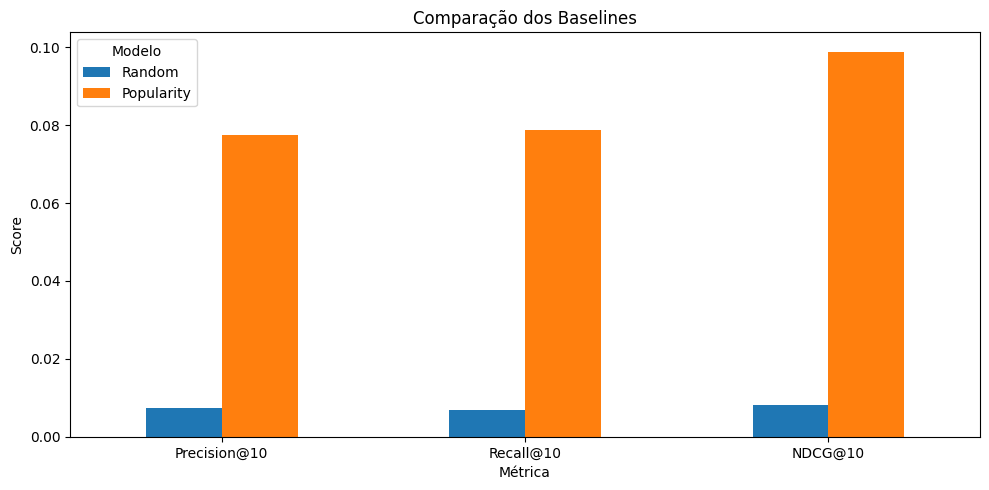

In [23]:
metrics = [
    f"Precision@{K}",
    f"Recall@{K}",
    f"NDCG@{K}"
]

comparison_plot = baseline_comparison.set_index("model")[metrics].T

comparison_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparação dos Baselines")
plt.xlabel("Métrica")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Modelo")
plt.tight_layout()

plt.show()

### 6.3 Ganho do Popularity sobre Random

Podemos quantificar o ganho relativo:

In [24]:
for metric in metrics:
    random_value = random_summary[metric]
    popularity_value = popularity_summary[metric]

    if random_value > 0:
        improvement = (
            (popularity_value - random_value)
            / random_value
            * 100
        )

        print(
            f"{metric}: "
            f"{improvement:.2f}% de ganho sobre Random"
        )

Precision@10: 949.25% de ganho sobre Random
Recall@10: 1031.81% de ganho sobre Random
NDCG@10: 1104.62% de ganho sobre Random


## 7. Análise por Usuário

As métricas médias resumem o desempenho global, mas podem esconder diferenças importantes entre usuários.

Por isso, será analisada a distribuição das métricas individuais dos dois baselines.

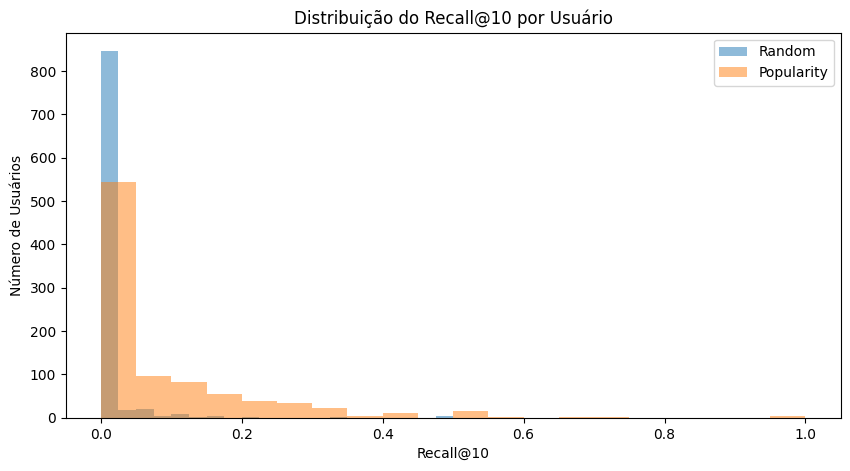

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(
    random_results[f"recall@{K}"],
    bins=20,
    alpha=0.5,
    label="Random"
)

plt.hist(
    popularity_results[f"recall@{K}"],
    bins=20,
    alpha=0.5,
    label="Popularity"
)

plt.title(f"Distribuição do Recall@{K} por Usuário")
plt.xlabel(f"Recall@{K}")
plt.ylabel("Número de Usuários")
plt.legend()

plt.show()

## 8. Cobertura do Catálogo

Além da relevância das recomendações, é importante observar quanto do catálogo cada modelo utiliza.

A cobertura do catálogo mede a proporção de itens distintos que aparecem em pelo menos uma lista de recomendação.

In [27]:
def catalog_coverage(recommendations, catalog):
    recommended_items = set()

    for items in recommendations.values():
        recommended_items.update(items)

    return len(recommended_items) / len(catalog)

In [28]:
random_coverage = catalog_coverage(
    random_recommendations,
    train_catalog
)

popularity_coverage = catalog_coverage(
    popularity_recommendations,
    train_catalog
)

print(f"Random coverage:     {random_coverage:.2%}")
print(f"Popularity coverage: {popularity_coverage:.2%}")

Random coverage:     99.63%
Popularity coverage: 4.47%


## 9. Conclusões

Os baselines estabelecem referências importantes para os próximos modelos.

O Random Baseline representa um cenário sem utilização de informação comportamental e serve como limite inferior simples de desempenho.

O Popularity Baseline explora apenas a frequência de interações dos itens e permite medir quanto desempenho pode ser obtido sem qualquer personalização.

A comparação entre os dois modelos também evidencia um possível trade-off entre relevância e cobertura do catálogo: estratégias baseadas em popularidade podem apresentar melhor desempenho em métricas Top-K, mas tendem a concentrar recomendações em um conjunto menor de itens.

Os próximos modelos deverão, portanto, ser avaliados não apenas em relação ao Random Baseline, mas principalmente em relação ao Popularity Baseline.

O próximo experimento será um sistema de **Content-Based Filtering**, utilizando os gêneros dos filmes para construir representações de itens e perfis de preferência dos usuários.